<a href="https://colab.research.google.com/github/Phalguni-dhabale/PR-LAB/blob/main/post_lab_PR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import deep learning libraries (TensorFlow/Keras)
import tensorflow as tf
from tensorflow import keras

# Import computer vision library
import cv2

print("Libraries imported successfully!")

Libraries imported successfully!


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape of training images: (60000, 28, 28)
Shape of training labels: (60000,)
Shape of test images: (10000, 28, 28)
Shape of test labels: (10000,)


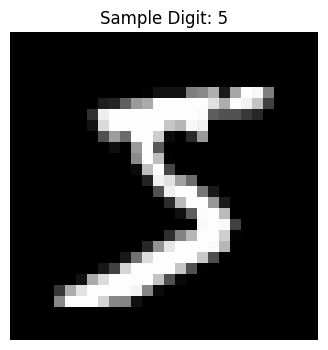

In [2]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Shape of training images: {x_train.shape}")
print(f"Shape of training labels: {y_train.shape}")
print(f"Shape of test images: {x_test.shape}")
print(f"Shape of test labels: {y_test.shape}")

# Display a sample digit
plt.figure(figsize=(4, 4))
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Sample Digit: {y_train[0]}")
plt.axis('off')
plt.show()

In [3]:
# Normalize the image data to [0, 1]
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

# Reshape images for CNN (add a channel dimension: (num_samples, height, width, channels))
# MNIST images are grayscale, so they have 1 channel.
img_rows, img_cols = x_train.shape[1], x_train.shape[2]
x_train_reshaped = x_train_normalized.reshape(x_train_normalized.shape[0], img_rows, img_cols, 1)
x_test_reshaped = x_test_normalized.reshape(x_test_normalized.shape[0], img_rows, img_cols, 1)

print(f"Shape of normalized and reshaped training images: {x_train_reshaped.shape}")
print(f"Shape of normalized and reshaped test images: {x_test_reshaped.shape}")

# Convert labels to one-hot encoding for categorical classification
num_classes = 10  # Digits 0-9
y_train_one_hot = keras.utils.to_categorical(y_train, num_classes)
y_test_one_hot = keras.utils.to_categorical(y_test, num_classes)

print(f"Shape of one-hot encoded training labels: {y_train_one_hot.shape}")
print(f"Shape of one-hot encoded test labels: {y_test_one_hot.shape}")

Shape of normalized and reshaped training images: (60000, 28, 28, 1)
Shape of normalized and reshaped test images: (10000, 28, 28, 1)
Shape of one-hot encoded training labels: (60000, 10)
Shape of one-hot encoded test labels: (10000, 10)


In [4]:
# Define the CNN model architecture
model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_rows, img_cols, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax') # Output layer for 10 classes (digits 0-9)
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train the model
history = model.fit(x_train_reshaped, y_train_one_hot,
                    epochs=5, # You can increase epochs for better accuracy
                    batch_size=32,
                    validation_split=0.1, # Use 10% of training data for validation
                    verbose=1)

print("\nModel training complete.")

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 58s 33ms/step - accuracy: 0.9568 - loss: 0.1403 - val_accuracy: 0.9840 - val_loss: 0.0518
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 54s 32ms/step - accuracy: 0.9854 - loss: 0.0471 - val_accuracy: 0.9828 - val_loss: 0.0561
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - accuracy: 0.9902 - loss: 0.0309 - val_accuracy: 0.9907 - val_loss: 0.0362
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9923 - loss: 0.0231 - val_accuracy: 0.9907 - val_loss: 0.0345
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 31ms/step - accuracy: 0.9945 - loss: 0.0165 - val_accuracy: 0.9888 - val_loss: 0.0399

Model training complete.


Test Loss: 0.0383
Test Accuracy: 0.9884


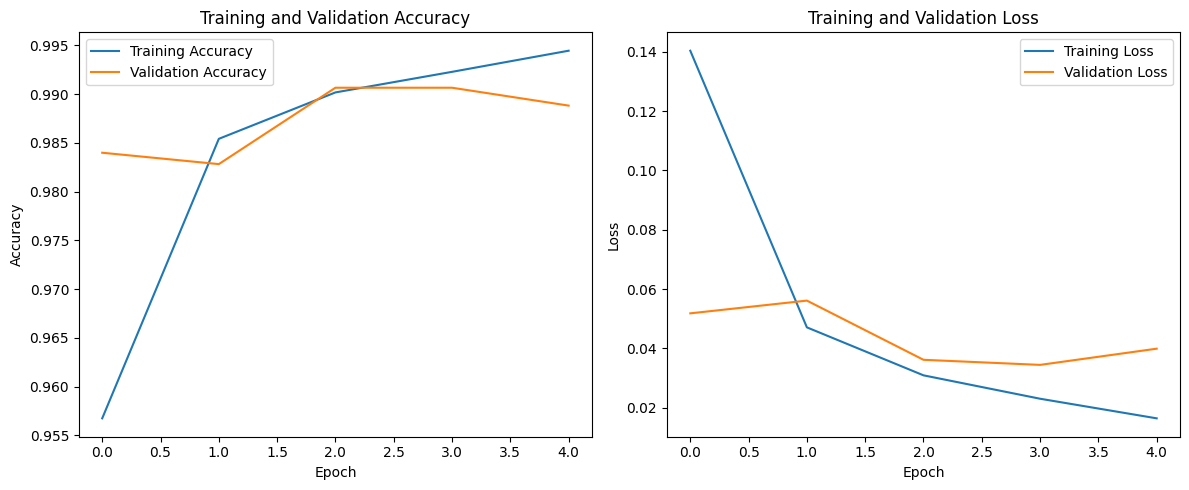

In [6]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(x_test_reshaped, y_test_one_hot, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Plot training history (accuracy and loss)
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


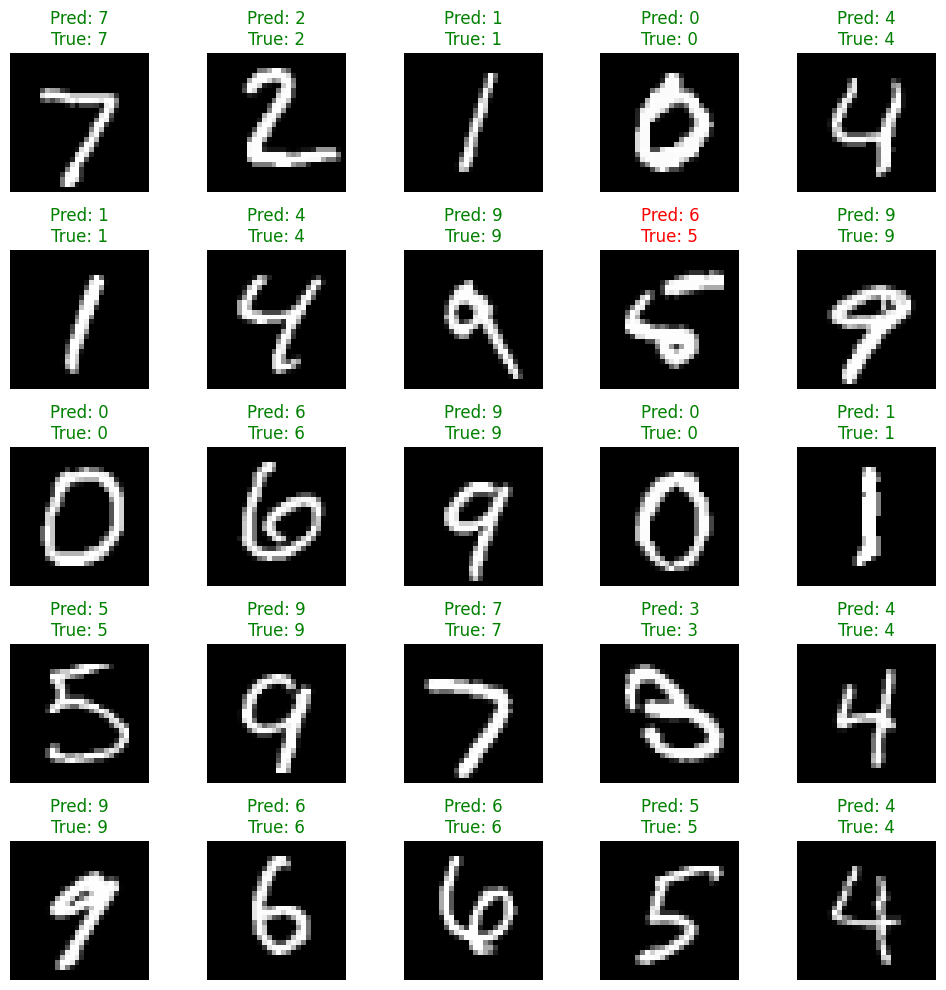

In [7]:
# Make predictions on the test dataset
predictions = model.predict(x_test_reshaped)

# Display some sample predictions
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    predicted_label = np.argmax(predictions[i])
    true_label = np.argmax(y_test_one_hot[i])
    plt.title(f"Pred: {predicted_label}\nTrue: {true_label}",
              color='green' if predicted_label == true_label else 'red')
    plt.axis('off')
plt.tight_layout()
plt.show()

Shape of flattened training images: (60000, 784)
Shape of flattened test images: (10000, 784)
Shape of training data after PCA: (60000, 50)
Shape of test data after PCA: (10000, 50)


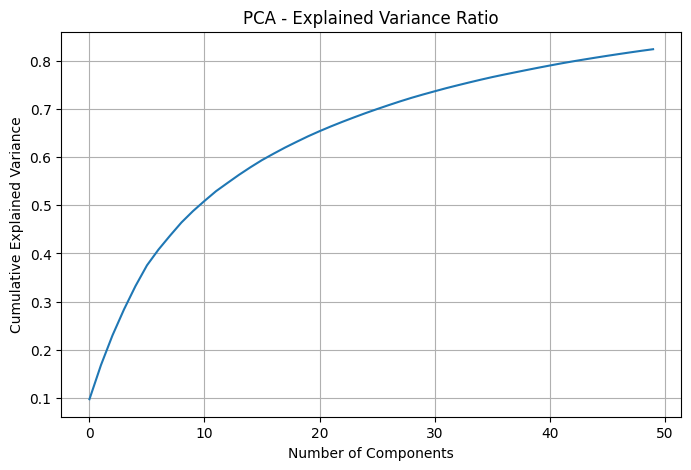

Feature extraction using PCA complete.


In [8]:
from sklearn.decomposition import PCA

# Flatten the images to 1D arrays for PCA
x_train_flat = x_train_normalized.reshape(x_train_normalized.shape[0], -1)
x_test_flat = x_test_normalized.reshape(x_test_normalized.shape[0], -1)

print(f"Shape of flattened training images: {x_train_flat.shape}")
print(f"Shape of flattened test images: {x_test_flat.shape}")

# Apply PCA for dimensionality reduction (feature extraction)
# Let's reduce dimensions to 50 principal components
pca = PCA(n_components=50)
x_train_pca = pca.fit_transform(x_train_flat)
x_test_pca = pca.transform(x_test_flat)

print(f"Shape of training data after PCA: {x_train_pca.shape}")
print(f"Shape of test data after PCA: {x_test_pca.shape}")

# Visualize the explained variance ratio
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance Ratio')
plt.grid(True)
plt.show()

print("Feature extraction using PCA complete.")

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train a Logistic Regression model on PCA-transformed data
logistic_model = LogisticRegression(max_iter=1000, solver='liblinear') # Increased max_iter for convergence
logistic_model.fit(x_train_pca, y_train)

# Make predictions on the test set
y_pred_logistic = logistic_model.predict(x_test_pca)

# Evaluate the model
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
print(f"Logistic Regression Test Accuracy (with PCA features): {accuracy_logistic:.4f}")
print("\nClassification Report (Logistic Regression with PCA features):\n")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Test Accuracy (with PCA features): 0.9046

Classification Report (Logistic Regression with PCA features):

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.92      0.87      0.89      1032
           3       0.88      0.90      0.89      1010
           4       0.89      0.92      0.90       982
           5       0.88      0.81      0.85       892
           6       0.93      0.95      0.94       958
           7       0.91      0.92      0.91      1028
           8       0.85      0.85      0.85       974
           9       0.88      0.86      0.87      1009

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Initialize KMeans with 10 clusters (since we have 10 digits)
kmeans = KMeans(n_clusters=num_classes, random_state=42, n_init=10)

# Fit KMeans to the PCA-transformed training data
kmeans.fit(x_train_pca)

# Get cluster labels for the training data
kmeans_labels = kmeans.labels_

# Evaluate clustering performance (against true labels, which makes it 'semi-supervised' evaluation)
# Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) are common metrics
ari_score = adjusted_rand_score(y_train, kmeans_labels)
nmi_score = normalized_mutual_info_score(y_train, kmeans_labels)

print(f"K-Means Clustering Adjusted Rand Index (ARI): {ari_score:.4f}")
print(f"K-Means Clustering Normalized Mutual Information (NMI): {nmi_score:.4f}")

# To visualize some clusters, we can plot the first two principal components
# and color them by cluster label
plt.figure(figsize=(10, 8))
plt.scatter(x_train_pca[:, 0], x_train_pca[:, 1], c=kmeans_labels, cmap='viridis', s=8, alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Cluster Centers')
plt.title('K-Means Clustering of MNIST (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()

print("Clustering analysis complete.")